# Chapter 3 &mdash; One-Dimensional Cellular Automata

Now the lattice is a row of cells (a circle, with wrap-around), and
we can see a CA's *entire history at a glance* by stacking
successive generations as rows of an image.

The star of this chapter is the idea that **additive** CA rules are
exactly **convolution kernels** &mdash; the same operation used to
filter signals and images. From this one idea flow fractals,
a polynomial algebra, and a bridge to digital signal processing.

In [1]:
# Setup: put the cadyn package on the path and enable inline figures.
# If you installed the package (`pip install -e .` from the repo root),
# the sys.path line is unnecessary.
import sys, pathlib
repo = pathlib.Path.cwd()
for _ in range(4):                      # find the repo root from anywhere
    if (repo / "cadyn").is_dir():
        break
    repo = repo.parent
sys.path.insert(0, str(repo))

%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (8, 5)

In [2]:
from cadyn import ca1d

## Transition rules as convolution kernels

Applying a kernel like $[1\,1\,1]$ means each new cell is the sum of
its neighborhood (mod $k$). Let's evolve $k=5$, $n=21$ from a single
seed and view time flowing **left to right** (one generation per
column), as in the book's Figure 2.

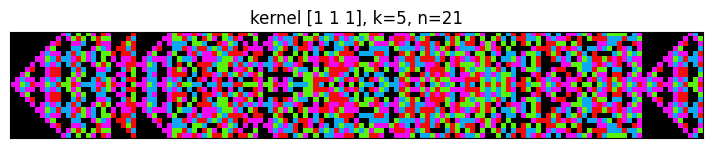

first 10 generations:
[[0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 1 1 1 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 1 2 3 2 1 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 1 3 1 2 1 3 1 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 1 4 0 1 4 1 0 4 1 0 0 0 0 0 0]
 [0 0 0 0 0 1 0 0 0 0 1 0 0 0 0 1 0 0 0 0 0]
 [0 0 0 0 1 1 1 0 0 1 1 1 0 0 1 1 1 0 0 0 0]
 [0 0 0 1 2 3 2 1 1 2 3 2 1 1 2 3 2 1 0 0 0]
 [0 0 1 3 1 2 1 4 4 1 2 1 4 4 1 2 1 3 1 0 0]
 [0 1 4 0 1 4 2 4 4 2 4 2 4 4 2 4 1 0 4 1 0]]


In [3]:
init = np.zeros(21, dtype=int); init[10] = 1
hist = ca1d.run_additive(init, [1, 1, 1], k=5, generations=136)
ca1d.plot_spacetime(hist, k=5, zero_color="black",
                    time_axis="right",
                    title="kernel [1 1 1], k=5, n=21")
plt.show()
print("first 10 generations:")
print(hist[:10])

## The Sierpi\u0144ski gasket from $[1\,0\,1] \bmod 2$

The neighborhood is just the two *outer* cells (the center is
excluded), summed mod 2. From a single seed this draws successive
approximations to **Sierpi\u0144ski's gasket** &mdash; a fractal.

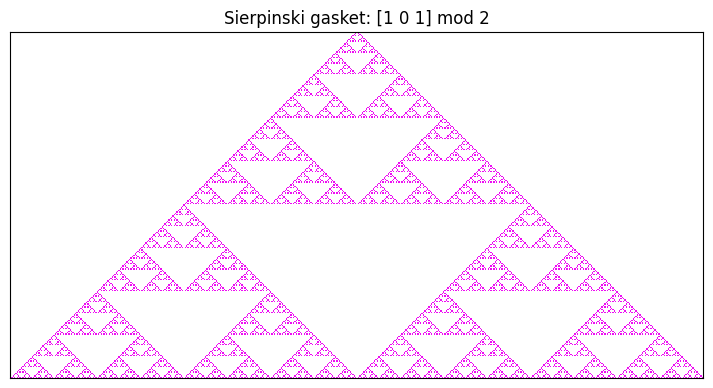

In [4]:
hist = ca1d.run_additive(ca1d.single_seed(512), [1, 0, 1],
                         k=2, generations=255)
ca1d.plot_spacetime(hist, k=2, title="Sierpinski gasket: [1 0 1] mod 2")
plt.show()

### More states, more structure

The same rule with more states (larger modulus $k$) gives richer
patterns. Prime moduli stay simple; composite moduli grow complex
with their number of factors.

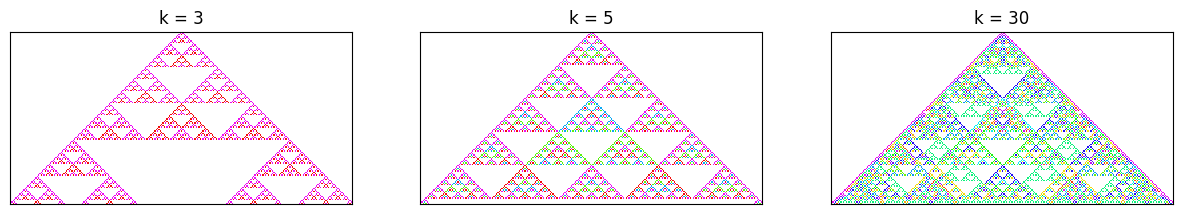

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, k in zip(axes, (3, 5, 30)):
    h = ca1d.run_additive(ca1d.single_seed(256), [1, 0, 1], k, 128)
    ca1d.plot_spacetime(h, k, ax=ax, title=f"k = {k}")
plt.show()

## Why? The polynomial representation

Represent a state as a polynomial $A(x)=\sum a_i x^i$ in
$\mathbb{Z}_k[x]/(x^n-1)$, and the kernel as $T(x)$. Then **one
generation is one multiplication**: $A^{(t+1)} = T(x)\,A^{(t)}$.
For $[1\,0\,1]$, $T(x) = x + x^{-1}$, and evolving a single seed
raises it to a power &mdash; the binomial coefficients
$\binom{t}{i} \bmod 2$ appear, which is *exactly* why the
Sierpi\u0144ski pattern shows up.

Let's confirm the polynomial step agrees with direct convolution.

In [6]:
n, k = 64, 5
init = ca1d.single_seed(n, value=3)
kp = ca1d.kernel_to_poly([1, 2, 3], n)
a, b = init.copy(), init.copy()
for _ in range(20):
    a = ca1d.convolve_step(a, [1, 2, 3], k)   # direct
    b = ca1d.poly_step(b, kp, k)              # polynomial
print("polynomial step == convolution step:", np.array_equal(a, b))

polynomial step == convolution step: True


## A non-additive rule: sum of squares

Not every rule is a convolution. The **sum-of-squares** rule
$C' = C_{i-1}^2 + 2C_i^2 + C_{i+1}^2 \pmod k$ is nonlinear, yet the
Sierpi\u0144ski gasket still surfaces whenever $k$ is a power of 2.

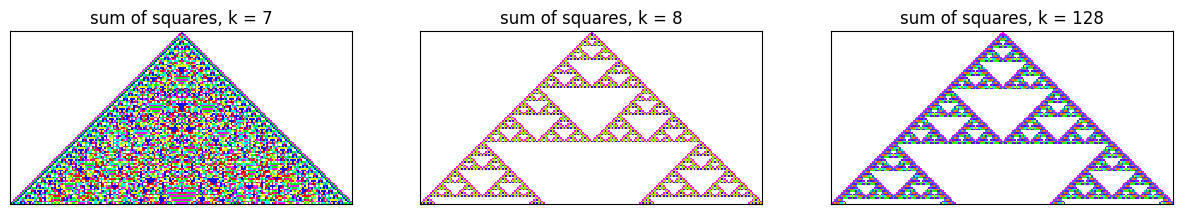

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, k in zip(axes, (7, 8, 128)):     # 8 and 128 are powers of 2
    step = ca1d.sum_of_squares_step(k)
    h = ca1d.run_rule(ca1d.single_seed(200), step, 100)
    ca1d.plot_spacetime(h, k, ax=ax, title=f"sum of squares, k = {k}")
plt.show()

## Entropy in one dimension

We can measure the **spatial entropy** of each generation &mdash;
how evenly the $k$ values populate the lattice. Different rules sit
at very different entropy levels: a freezing rule collapses to 0, a
thorough mixer hovers near $\log_2 k$, and the particle-forming
1-D Life settles in between.

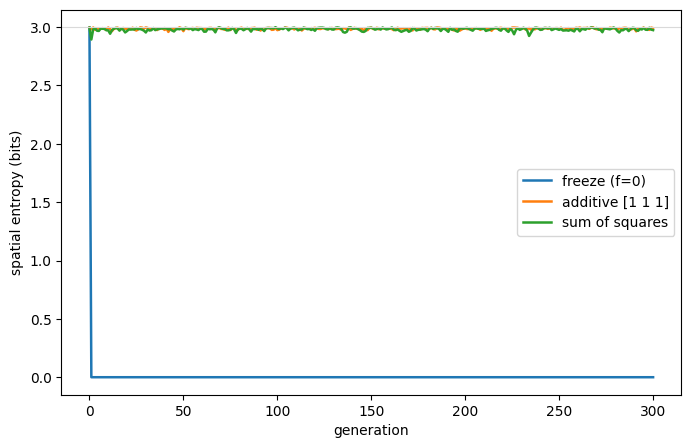

In [8]:
rng = np.random.default_rng(5)
n, gens, k = 400, 300, 8
x0 = rng.integers(0, k, n)

runs = {
    "freeze (f=0)":       ca1d.run_rule(x0, lambda x: np.zeros_like(x), gens),
    "additive [1 1 1]":   ca1d.run_additive(x0, [1, 1, 1], k, gens),
    "sum of squares":     ca1d.run_rule(x0, ca1d.sum_of_squares_step(k), gens),
}
fig, ax = plt.subplots()
for label, h in runs.items():
    ax.plot(ca1d.spatial_entropy(h, k), lw=1.8, label=label)
ax.axhline(np.log2(k), color="0.85", lw=0.8)
ax.set_xlabel("generation"); ax.set_ylabel("spatial entropy (bits)")
ax.legend(); plt.show()

## Your turn

1. Try asymmetric kernels like `[1, 2, 3]` or longer ones like
   `[1, 0, 0, 0, 1]` at various $k$.
2. Evolve the **1-D Game of Life** and look for particle-like
   tracks:
   ```python
   rng = np.random.default_rng(7)
   x0 = np.where(rng.random(512) < 0.5, rng.integers(1, 256, 512), 0)
   h = ca1d.run_rule(x0, ca1d.life_1d_step(rng), 300)
   ca1d.plot_spacetime(h, 256, time_axis="right"); plt.show()
   ```
3. Which of your rules keep entropy high, and which drive it down?